Динамика модели DaisyWorld

In [1]:
# Цель

Построить комплексный график изменения численности маргариток,
температуры и светимости при изменяющейся солнечной активности.
Импорт библиотек

In [2]:
using DrWatson
@quickactivate "project"
using Agents
using DataFrames
using Plots

  Activating project at `~/2026-1--study--simulation-modeling/labs/lab03/project`


## Загрузка модели

In [3]:
include(srcdir("daisyworld.jl"))

using CairoMakie

##Определение функции для подсчета

In [4]:
black(a) = a.breed == :black
white(a) = a.breed == :white

white (generic function with 1 method)

## Настройка сбора данных

In [5]:
adata = [(black, count), (white, count)]

model = daisyworld(solar_luminosity = 1.0, scenario = :ramp)

temperature(model) = StatsBase.mean(model.temperature)
mdata = [temperature, :solar_luminosity]

agent_df, model_df = run!(model, 1000; adata = adata, mdata = mdata)

(1001×3 DataFrame
  Row │ time   count_black  count_white 
      │ Int64  Int64        Int64       
──────┼─────────────────────────────────
    1 │     0          180          180
    2 │     1          421          168
    3 │     2          577          222
    4 │     3          606          270
    5 │     4          603          291
    6 │     5          598          297
    7 │     6          593          301
    8 │     7          586          309
  ⋮   │   ⋮         ⋮            ⋮
  995 │   994            0          899
  996 │   995            0          898
  997 │   996            0          894
  998 │   997            0          891
  999 │   998            0          894
 1000 │   999            0          883
 1001 │  1000            0          877
                        986 rows omitted, 1001×3 DataFrame
  Row │ time   temperature  solar_luminosity 
      │ Int64  Float64      Float64          
──────┼──────────────────────────────────────
    1 │     0     16.9135  

## Построение графика

In [6]:
figure = CairoMakie.Figure(size = (600, 600));

Численность

In [7]:
ax1 = figure[1, 1] = Axis(figure, ylabel = "daisy count")
blackl = lines!(ax1, agent_df[!, :time], agent_df[!, :count_black], color = :red)
whitel = lines!(ax1, agent_df[!, :time], agent_df[!, :count_white], color = :blue)
figure[1, 2] = Legend(figure, [blackl, whitel], ["black", "white"])

Makie.Legend()

Температура

In [8]:
ax2 = figure[2, 1] = Axis(figure, ylabel = "temperature")

Makie.Axis with 0 plots:


Светимость

In [9]:
ax3 = figure[3, 1] = Axis(figure, xlabel = "tick", ylabel = "luminosity")
lines!(ax2, model_df[!, :time], model_df[!, :temperature], color = :red)
lines!(ax3, model_df[!, :time], model_df[!, :solar_luminosity], color = :red)

Makie.Lines{Tuple{Vector{GeometryBasics.Point{2, Float64}}}}

Оформление

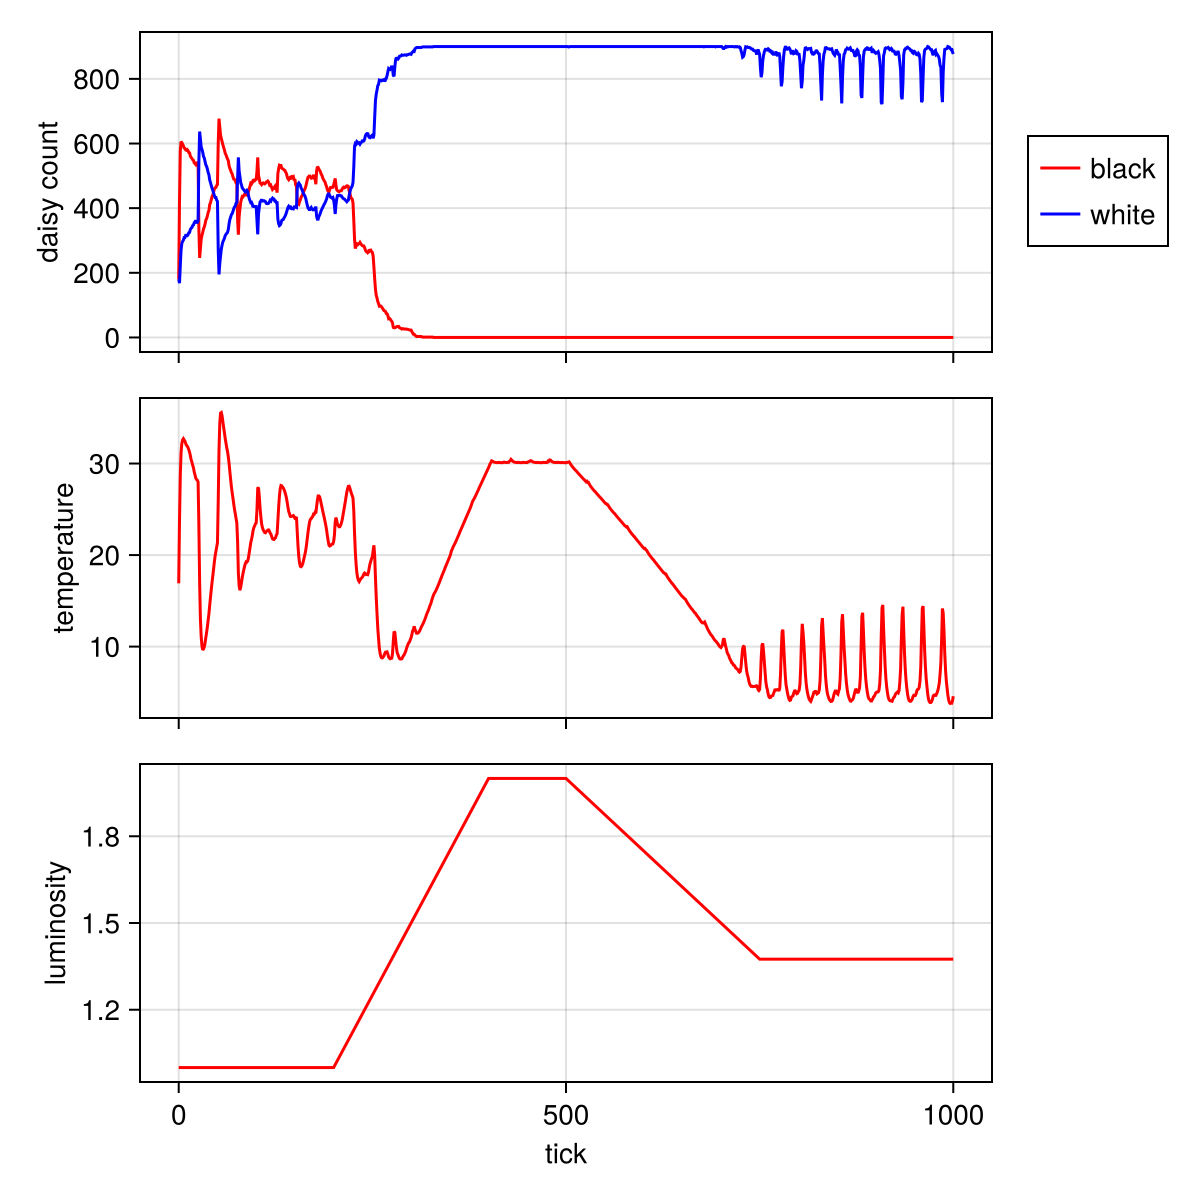

In [10]:
for ax in (ax1, ax2); ax.xticklabelsvisible = false; end
figure

## Сохранение

In [11]:
save(plotsdir("daisy_luminosity.png"), figure)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*